In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Read Data

In [3]:
# https://www.kaggle.com/datasets/danb91/covid-ppp-loan-data-with-fraud-examples
df = pd.read_csv("C:/Users/caleb/Downloads/ppploan/ppp_over_150k.csv")
df

,LoanNumber,DateApproved,SBAOfficeCode,ProcessingMethod,BorrowerName,BorrowerAddress,BorrowerCity,BorrowerState,BorrowerZip,LoanStatusDate,...,TOTAL_PROCEED,PROCEED_Diff,UTILITIES_PROCEED_pct,PAYROLL_PROCEED_pct,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job
0,9547507704,2020-05-01,464,PPP,sumter coatings inc,2410 highway 15 south,sumter,UNK,29150-9662,2020-12-18,...,769358.78,0.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,12409.01
1,9777677704,2020-05-01,464,PPP,pleasant places inc,7684 southrail road,north charleston,UNK,29420-9000,2021-09-28,...,736927.79,0.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,10094.90
2,5791407702,2020-05-01,1013,PPP,boyer childrens clinic,1850 boyer ave e,seattle,UNK,98112-2922,2021-03-17,...,691355.00,0.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,9218.07
3,6223567700,2020-05-01,920,PPP,kirtley construction inc,1661 martin ranch rd,san bernardino,UNK,92407-1740,2021-10-16,...,499871.00,0.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,23803.38
4,9662437702,2020-05-01,101,PPP,aero box llc,unknown,unknown,UNK,0,2021-08-17,...,367437.00,0.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,14697.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968527,4395967002,2020-04-03,897,PPP,roy e paulson jr pc,102 n kenwood,casper,WY,82601-2724,2021-01-13,...,150000.00,0.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,10000.00
968528,6985647108,2020-04-14,897,PPP,sweetwater county child developmental center inc,1715 hitching post dr,green river,WY,82935-5783,2020-12-08,...,150000.00,0.0,0.033,0.967,0.0,0.0,0.0,0.0,0.0,3452.38
968529,7996438405,2021-02-12,897,PPS,electrical systems of wyoming inc,1105 adon rd,rozet,WY,82727-8465,2021-09-15,...,149998.00,2.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,29999.40
968530,9054647103,2020-04-15,897,PPP,eden life care,30 n gould street ste 4000,sheridan,WY,82801,2022-03-08,...,150000.00,0.0,0.000,1.000,0.0,0.0,0.0,0.0,0.0,21428.57


In [4]:
fraud_df = pd.read_csv("C:/Users/caleb/Downloads/ppploan/ppp_fraud_cases.csv")
fraud_df

,Company,State,Source,Suspects
0,apollo hp inc,CA,https://www.justice.gov/usao-edca/pr/rocklin-b...,"[['Kevin Lee Co', 'CA']]"
1,power house sports academy,GA,https://www.justice.gov/opa/pr/six-charged-con...,"[['Rodericque Thompson', 'GA'], ['Micah K Bais..."
2,faithful transport services llc,SC,https://www.justice.gov/opa/pr/six-charged-con...,"[['Rodericque Thompson', 'GA'], ['Travis C Cro..."
3,kmj transport llc,SC,https://www.justice.gov/opa/pr/six-charged-con...,"[['Rodericque Thompson', 'GA'], ['Keith A Malo..."
4,market yourself inc,GA,https://www.justice.gov/opa/pr/six-charged-con...,"[['Rodericque Thompson', 'GA'], ['Tabronx W Sm..."
...,...,...,...,...
95,pink lady line,TX,https://www.justice.gov/usao-sdtx/pr/local-wom...,"[['LaDonna Wiggins', 'TX']]"
96,guardian of humanity inc,AZ,https://www.justice.gov/usao-wdny/pr/north-chi...,"[['Michael Rech', 'NY']]"
97,skilled trade investments lp,TX,https://www.justice.gov/opa/pr/texas-man-arres...,"[['Scott Jackson Davis', 'TX']]"
98,skilled trade staffing llc,TX,https://www.justice.gov/opa/pr/texas-man-arres...,"[['Scott Jackson Davis', 'TX']]"


In [5]:
# Label the fraudulent rows based on company names in the label dataset
df['Fraud'] = df['BorrowerName'].isin(fraud_df['Company']).astype(int)

In [6]:
# Sanity check the join
len(fraud_df['Company'].unique())

100

In [7]:
# We only see 83 of the 100 fraudulent companies... there may be invalid company names in the labels or overall dataset
len(set(df[df['Fraud'] == 1]['BorrowerName'].unique()))

83

In [8]:
not_found_fraudulent_companies = set(
    fraud_df['Company'].unique()
).difference(set(
    df[df['Fraud'] == 1]['BorrowerName'].unique()
))
not_found_fraudulent_companies

{'aboveall business',
 'all star room and board services of michigan inc',
 'blue flight logistics llc',
 'dituri construction llc',
 'eni operation co',
 'eric r shibley md pllc',
 'es1 llc',
 'maturino enterprises',
 'nkb enterprise llc',
 'pinnacle industry inc',
 'seattles finest cannabis llc',
 'sfc llc',
 'showtime trucking xpo inc',
 'ss1 llc',
 'velocity innovations',
 'visla captial llc',
 'wingate funeral service group'}

In [9]:
# Transforming the company names to make the search less stringent. We may be able to manually label by doing this. I will skip it for now but this may be a way to get a larger count of positive class for the labels by manually labeling
companies = [
    'aboveall',
    'all star room',
    'blue flight',
    'dituri',
    'eni operation',
    'shibley',
    'es1',
    'maturino',
    'nkb enterprise',
    'pinnacle industry',
    'seattles finest cannabis',
    'sfc',
    'showtime trucking ',
    'ss1',
    'velocity',
    'visla captial ',
    'wingate funeral'
]
for c in companies:
    print(f"{c}: {df['BorrowerName'].str.contains(c).any()}")
    print(df[df['BorrowerName'].str.contains(c, na=False)]['BorrowerName'])
    print('\n')

aboveall: False
Series([], Name: BorrowerName, dtype: object)


all star room: True
454316    all star room  board services of michigan inc
Name: BorrowerName, dtype: object


blue flight: False
Series([], Name: BorrowerName, dtype: object)


dituri: True
588733    drs gardiner  dituri pasba small 7a term
Name: BorrowerName, dtype: object


eni operation: False
Series([], Name: BorrowerName, dtype: object)


shibley: True
371855                  shibleyville llc
373694                  shibleyville llc
623978          shibley operating co llc
623979          shibley operating co llc
680901            shibley management inc
684010            shibley management inc
692598    spangenberg shibley  liber llp
692680    spangenberg shibley  liber llp
Name: BorrowerName, dtype: object


es1: True
25546     connie a hottmann dba gampg enterprises1
85495                               pawsibilities1
107014                          pawsibilities1 inc
697585                   gc aviation services1 

## Summarize Data

In [10]:
df.describe()

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,LoanNumber,SBAOfficeCode,Term,SBAGuarantyPercentage,InitialApprovalAmount,CurrentApprovalAmount,UndisbursedAmount,ServicingLenderLocationID,JobsReported,NAICSCode,...,PROCEED_Diff,UTILITIES_PROCEED_pct,PAYROLL_PROCEED_pct,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud
count,9.685320e+05,968532.000000,968532.000000,968532.0,9.685320e+05,9.685320e+05,9.685320e+05,968532.000000,968532.000000,968532.000000,...,9.685320e+05,968532.000000,968532.000000,968532.000000,968532.000000,968532.000000,968532.000000,968532.000000,968532.0000,968532.000000
mean,5.427133e+09,571.520066,36.297555,100.0,5.322552e+05,5.306236e+05,1.207811e+01,107924.839664,51.886761,508303.446845,...,2.218373e+00,0.009156,0.971467,0.003424,0.010715,0.000412,0.004105,0.000716,inf,0.000098
std,2.551320e+09,263.025314,17.214728,0.0,7.442512e+05,7.378869e+05,4.776398e+03,132637.319901,67.551868,185421.574560,...,5.341029e+02,0.047811,0.085583,0.029104,0.041067,0.016914,0.023227,0.010371,NaN,0.009903
min,1.000007e+09,101.000000,0.000000,100.0,0.000000e+00,1.500000e+05,0.000000e+00,20.000000,0.000000,81.000000,...,-1.499700e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
25%,3.271096e+09,373.000000,24.000000,100.0,2.002000e+05,2.004000e+05,0.000000e+00,30804.000000,18.000000,335999.000000,...,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7718.4450,0.000000
50%,5.400677e+09,515.000000,24.000000,100.0,2.951788e+05,2.950000e+05,0.000000e+00,57328.000000,30.000000,541211.000000,...,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11170.5900,0.000000
75%,7.546310e+09,811.000000,60.000000,100.0,5.402000e+05,5.393898e+05,0.000000e+00,116998.000000,54.000000,622110.000000,...,5.820766e-11,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15074.9475,0.000000
max,9.999007e+09,1094.000000,120.000000,100.0,1.000000e+07,1.000000e+07,3.397100e+06,533479.000000,500.000000,999990.000000,...,3.237070e+05,1.000000,1.041000,1.000000,1.000000,1.000000,1.000000,1.000000,inf,1.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 968532 entries, 0 to 968531
Data columns (total 67 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   LoanNumber                     968532 non-null  int64  
 1   DateApproved                   968532 non-null  object 
 2   SBAOfficeCode                  968532 non-null  int64  
 3   ProcessingMethod               968532 non-null  object 
 4   BorrowerName                   968525 non-null  object 
 5   BorrowerAddress                968532 non-null  object 
 6   BorrowerCity                   968532 non-null  object 
 7   BorrowerState                  968532 non-null  object 
 8   BorrowerZip                    968532 non-null  object 
 9   LoanStatusDate                 968532 non-null  object 
 10  LoanStatus                     968532 non-null  object 
 11  Term                           968532 non-null  int64  
 12  SBAGuarantyPercentage         

There are no missing values

## Check for Infinite Numeric Values and Duplicates

In [12]:
numeric_df = df.select_dtypes(include=[np.number])

# Find rows where ANY column has an infinite value
rows_with_inf = df[np.isinf(numeric_df).any(axis=1)]
rows_with_inf

,LoanNumber,DateApproved,SBAOfficeCode,ProcessingMethod,BorrowerName,BorrowerAddress,BorrowerCity,BorrowerState,BorrowerZip,LoanStatusDate,...,PROCEED_Diff,UTILITIES_PROCEED_pct,PAYROLL_PROCEED_pct,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud
123812,6557167306,2020-04-30,914,PPP,st margaret mary school,25515 eshelman,lomita,CA,90717,2021-10-21,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,inf,0
550932,5780187005,2020-04-06,766,PPP,reliant transportation inc,4411 s 86th street,lincoln,NE,68526-9225,2021-03-11,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,inf,0
763783,4864227203,2020-04-27,303,PPP,vincera rehab llc,1200 constitution ave ste 210,philadelphia,PA,19112-1306,2021-04-14,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,inf,0
967206,4563247009,2020-04-03,897,PPP,weeden construction llc,402 murphy gulch rd,banner,WY,82832-9726,2020-12-15,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,inf,0


In [13]:
# We will replaced these inf values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [14]:
# There are no duplicates
duplicates = df[df.duplicated(keep=False)]
duplicates

,LoanNumber,DateApproved,SBAOfficeCode,ProcessingMethod,BorrowerName,BorrowerAddress,BorrowerCity,BorrowerState,BorrowerZip,LoanStatusDate,...,PROCEED_Diff,UTILITIES_PROCEED_pct,PAYROLL_PROCEED_pct,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud


## Check for Inconsistent Data

In [15]:
# Validate amounts
amount_cols = [c for c in df.columns if "Amount" in c]
for a in amount_cols:
    print(f"Column: {a}")
    print(f"Min Val: {df[a].min()}, Max Val: {df[a].max()}")
    print(f"Number of occurences of Min Val: {len(df[df[a] == df[a].min()])}, number of occurences of Max Val: {len(df[df[a] == df[a].max()])}")
    print("\n")

Column: InitialApprovalAmount
Min Val: 0.0, Max Val: 10000000.0
Number of occurences of Min Val: 2, number of occurences of Max Val: 747


Column: CurrentApprovalAmount
Min Val: 150000.0, Max Val: 10000000.0
Number of occurences of Min Val: 6690, number of occurences of Max Val: 707


Column: UndisbursedAmount
Min Val: 0.0, Max Val: 3397100.0
Number of occurences of Min Val: 968515, number of occurences of Max Val: 1


Column: ForgivenessAmount
Min Val: 0.0, Max Val: 10196272.22
Number of occurences of Min Val: 93710, number of occurences of Max Val: 1


Column: NotForgivenAmount
Min Val: -196272.22000000067, Max Val: 10000000.0
Number of occurences of Min Val: 1, number of occurences of Max Val: 118




For InitialApprovalAmount, CurrentApprovalAmount, and NotForgivenAmount, the maximum value of 10000000.0 being common makes sense since the maximum allowed amount was $10,000,000 for an individual borrower (https://www.jw.com/news/insights-2021-paycheck-protection-program-loans/)

For CurrentApprovalAmount, the 150,000 minimum looks to be clipped. It is likely 150k loans or lower

The rest of the amounts do not seem to be inconsistent

In [16]:
# Validate proceeds
proceed_cols = [c for c in df.columns if "PROCEED" in c]
for p in proceed_cols:
    print(f"Column: {p}")
    print(f"Min Val: {df[p].min()}, Max Val: {df[p].max()}")
    print(f"Number of occurences of Min Val: {len(df[df[p] == df[p].min()])}, number of occurences of Max Val: {len(df[df[p] == df[p].max()])}")
    print("\n")

Column: UTILITIES_PROCEED
Min Val: 0.0, Max Val: 10000000.0
Number of occurences of Min Val: 635755, number of occurences of Max Val: 1


Column: PAYROLL_PROCEED
Min Val: 0.0, Max Val: 10000000.0
Number of occurences of Min Val: 1931, number of occurences of Max Val: 512


Column: MORTGAGE_INTEREST_PROCEED
Min Val: 0.0, Max Val: 10000000.0
Number of occurences of Min Val: 939898, number of occurences of Max Val: 1


Column: RENT_PROCEED
Min Val: 0.0, Max Val: 5518277.93
Number of occurences of Min Val: 875030, number of occurences of Max Val: 1


Column: REFINANCE_EIDL_PROCEED
Min Val: 0.0, Max Val: 2951590.0
Number of occurences of Min Val: 966784, number of occurences of Max Val: 1


Column: HEALTH_CARE_PROCEED
Min Val: 0.0, Max Val: 3880000.0
Number of occurences of Min Val: 916822, number of occurences of Max Val: 1


Column: DEBT_INTEREST_PROCEED
Min Val: 0.0, Max Val: 2497617.0
Number of occurences of Min Val: 952173, number of occurences of Max Val: 1


Column: TOTAL_PROCEED
Min

The proceed columns tell a similar story. Some max out at $10,000,000. The minimums are mostly $0. No inconsistent data looks to be present

The following numeric columns should not be used for modeling:
- Loan Number (ID)
- SBAOfficeCode (ID, though maybe it matters if certain locations are approving all fraudulent loans)
- SBAGuarantyPercentage(Always value 100)
- UndisbursedAmount (Always value 0)
- ServicingLenderLocationID (ID)
- NAICSCode (ID)
- OriginatingLenderLocationID (ID)

The following column have numeric dtype but are categorical
- Term

The following non-numeric columns should not be used for modeling:
- BorrowerAddress (Random string)
- BorrowerName (Random string)
- Ethnicity (Bias)
- FranchiseName (random str)
- Gender (Bias)
- OriginatingLender (Random str)
- Race (bias)
- ServicingLenderAddress (random str)
- ServicingLenderName (random str)

There are also a few non-numeric columns that are categorical but have many values. I will skip them for initial analysis but may revisit them if they end up being useful
- BorrowerCity (categorical but not specific enough to be useful)
- BorrowerZip (categorical but not specific enough to be useful)
- CD (categorical but not specific enough to be useful)
- OriginatingLenderCity (categorical but not specific enough to be useful)
- ProjectCity (categorical but not specific enough to be useful)
- ProjectCountyName (categorical but not specific enough to be useful)
- ProjectZip (categorical but not specific enough to be useful)
- ServicingLenderCity (categorical but not specific enough to be useful)
- ServicingLenderZip (categorical but not specific enough to be useful)

Non numeric cols which can be used for modeling (one hot/ordinal encoding or datetime to numeric conversion)
- BusinessType (categorical)
- BusinessAgeDescription (categorical)
- DateApproved (datetime, maybe convert to int)
- ForgivenessDate (datetime, maybe convert to int)
- HubzoneIndicator (categorical)
- LMIndicator (categorical)
- LoanStatus (categorical)
- LoanStatusDate (datetime, maybe convert to int)
- NonProfit (categorical)
- ProcessingMethod (categorical)
- RuralUrbanIndicator (categorical)
- Veteran (categorical)


In [17]:
numeric_cols_to_drop = [
    'LoanNumber',
    'SBAOfficeCode',
    'SBAGuarantyPercentage',
    'UndisbursedAmount',
    'ServicingLenderLocationID',
    'NAICSCode',
    'OriginatingLenderLocationID',
]

In [18]:
non_numeric_cols_to_drop = [
    'BorrowerCity',
    'BorrowerZip',
    'CD',
    'OriginatingLenderCity',
    'ProjectCity',
    'ProjectCountyName',
    'ProjectZip',
    'ServicingLenderCity',
    'ServicingLenderZip',
    'BorrowerAddress',
    'BorrowerName',
    'Ethnicity',
    'FranchiseName',
    'Gender',
    'OriginatingLender',
    'Race',
    'ServicingLenderAddress',
    'ServicingLenderName',
]

In [19]:
columns_to_drop = set(numeric_cols_to_drop).union(set(non_numeric_cols_to_drop))
df = df.drop(columns_to_drop, axis=1)

In [20]:
numeric_cols = df.select_dtypes(include='number').columns
non_numeric_cols = df.columns.difference(numeric_cols)

In [21]:
len(numeric_cols)

26

In [22]:
len(non_numeric_cols)

16

## Histograms

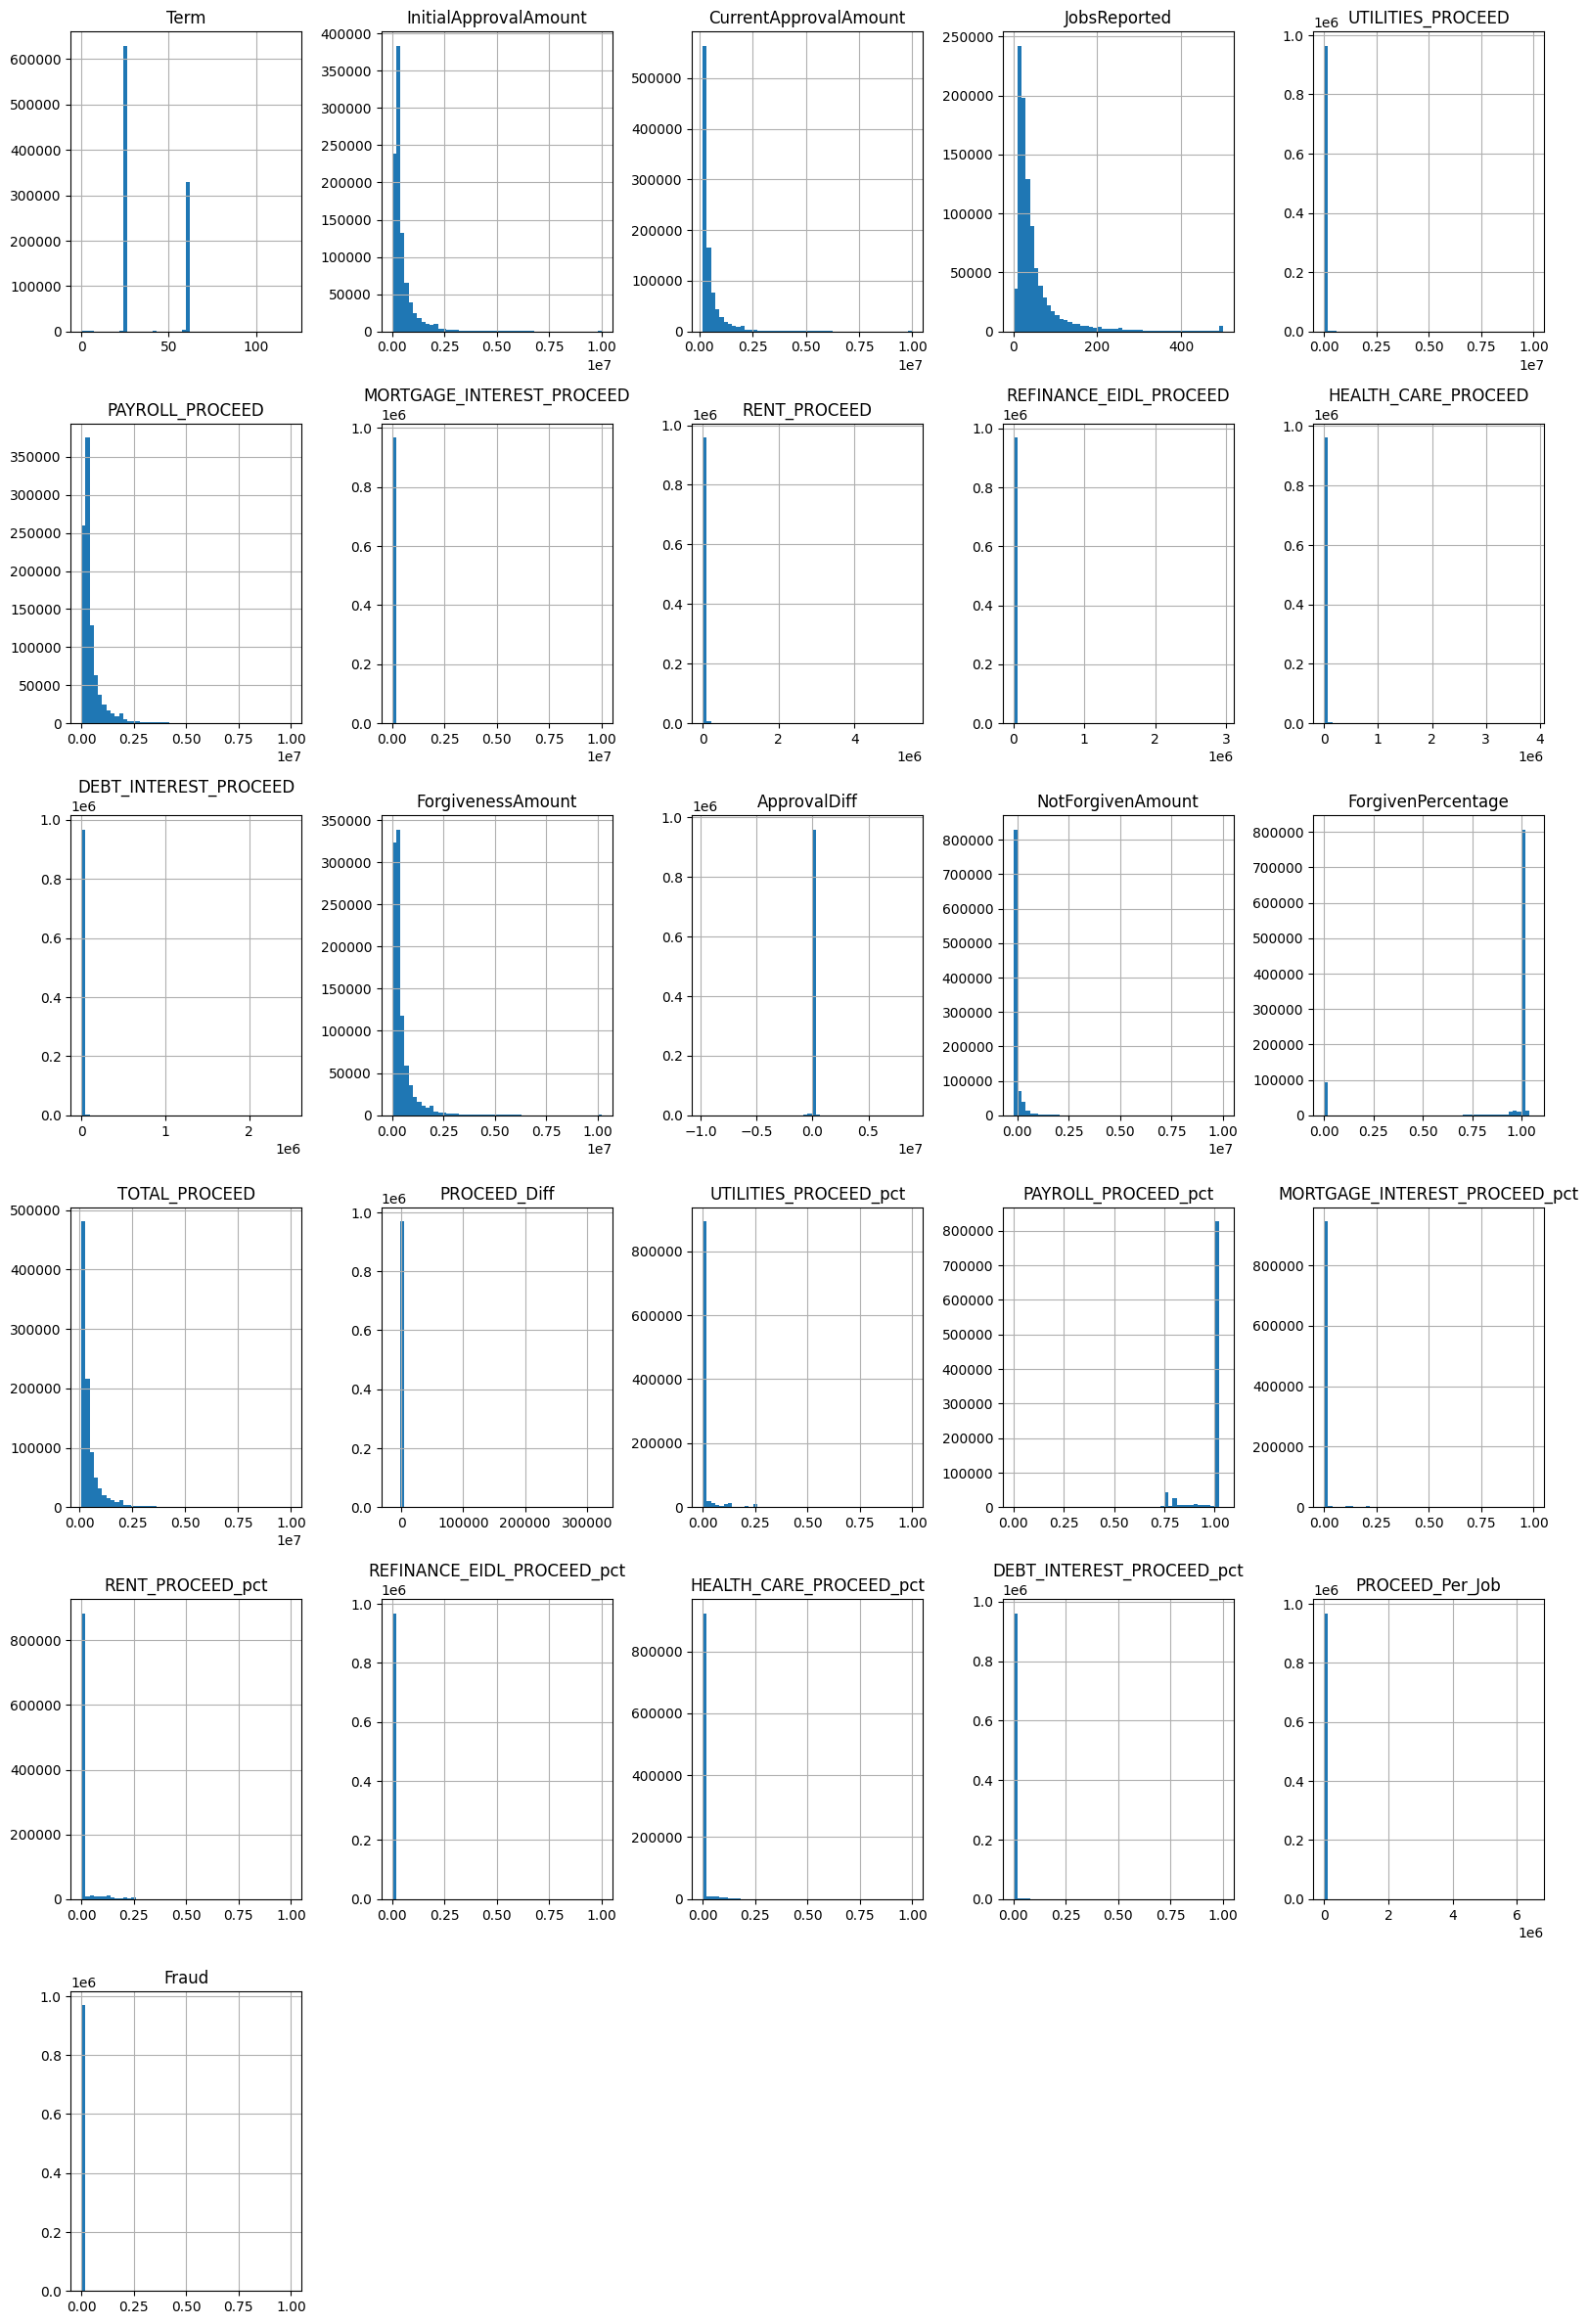

In [23]:
df[numeric_cols].hist(column=numeric_cols, figsize=(16, 24), bins=50)
plt.tight_layout()
None

## Violin Plots

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\numpy\linalg\_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


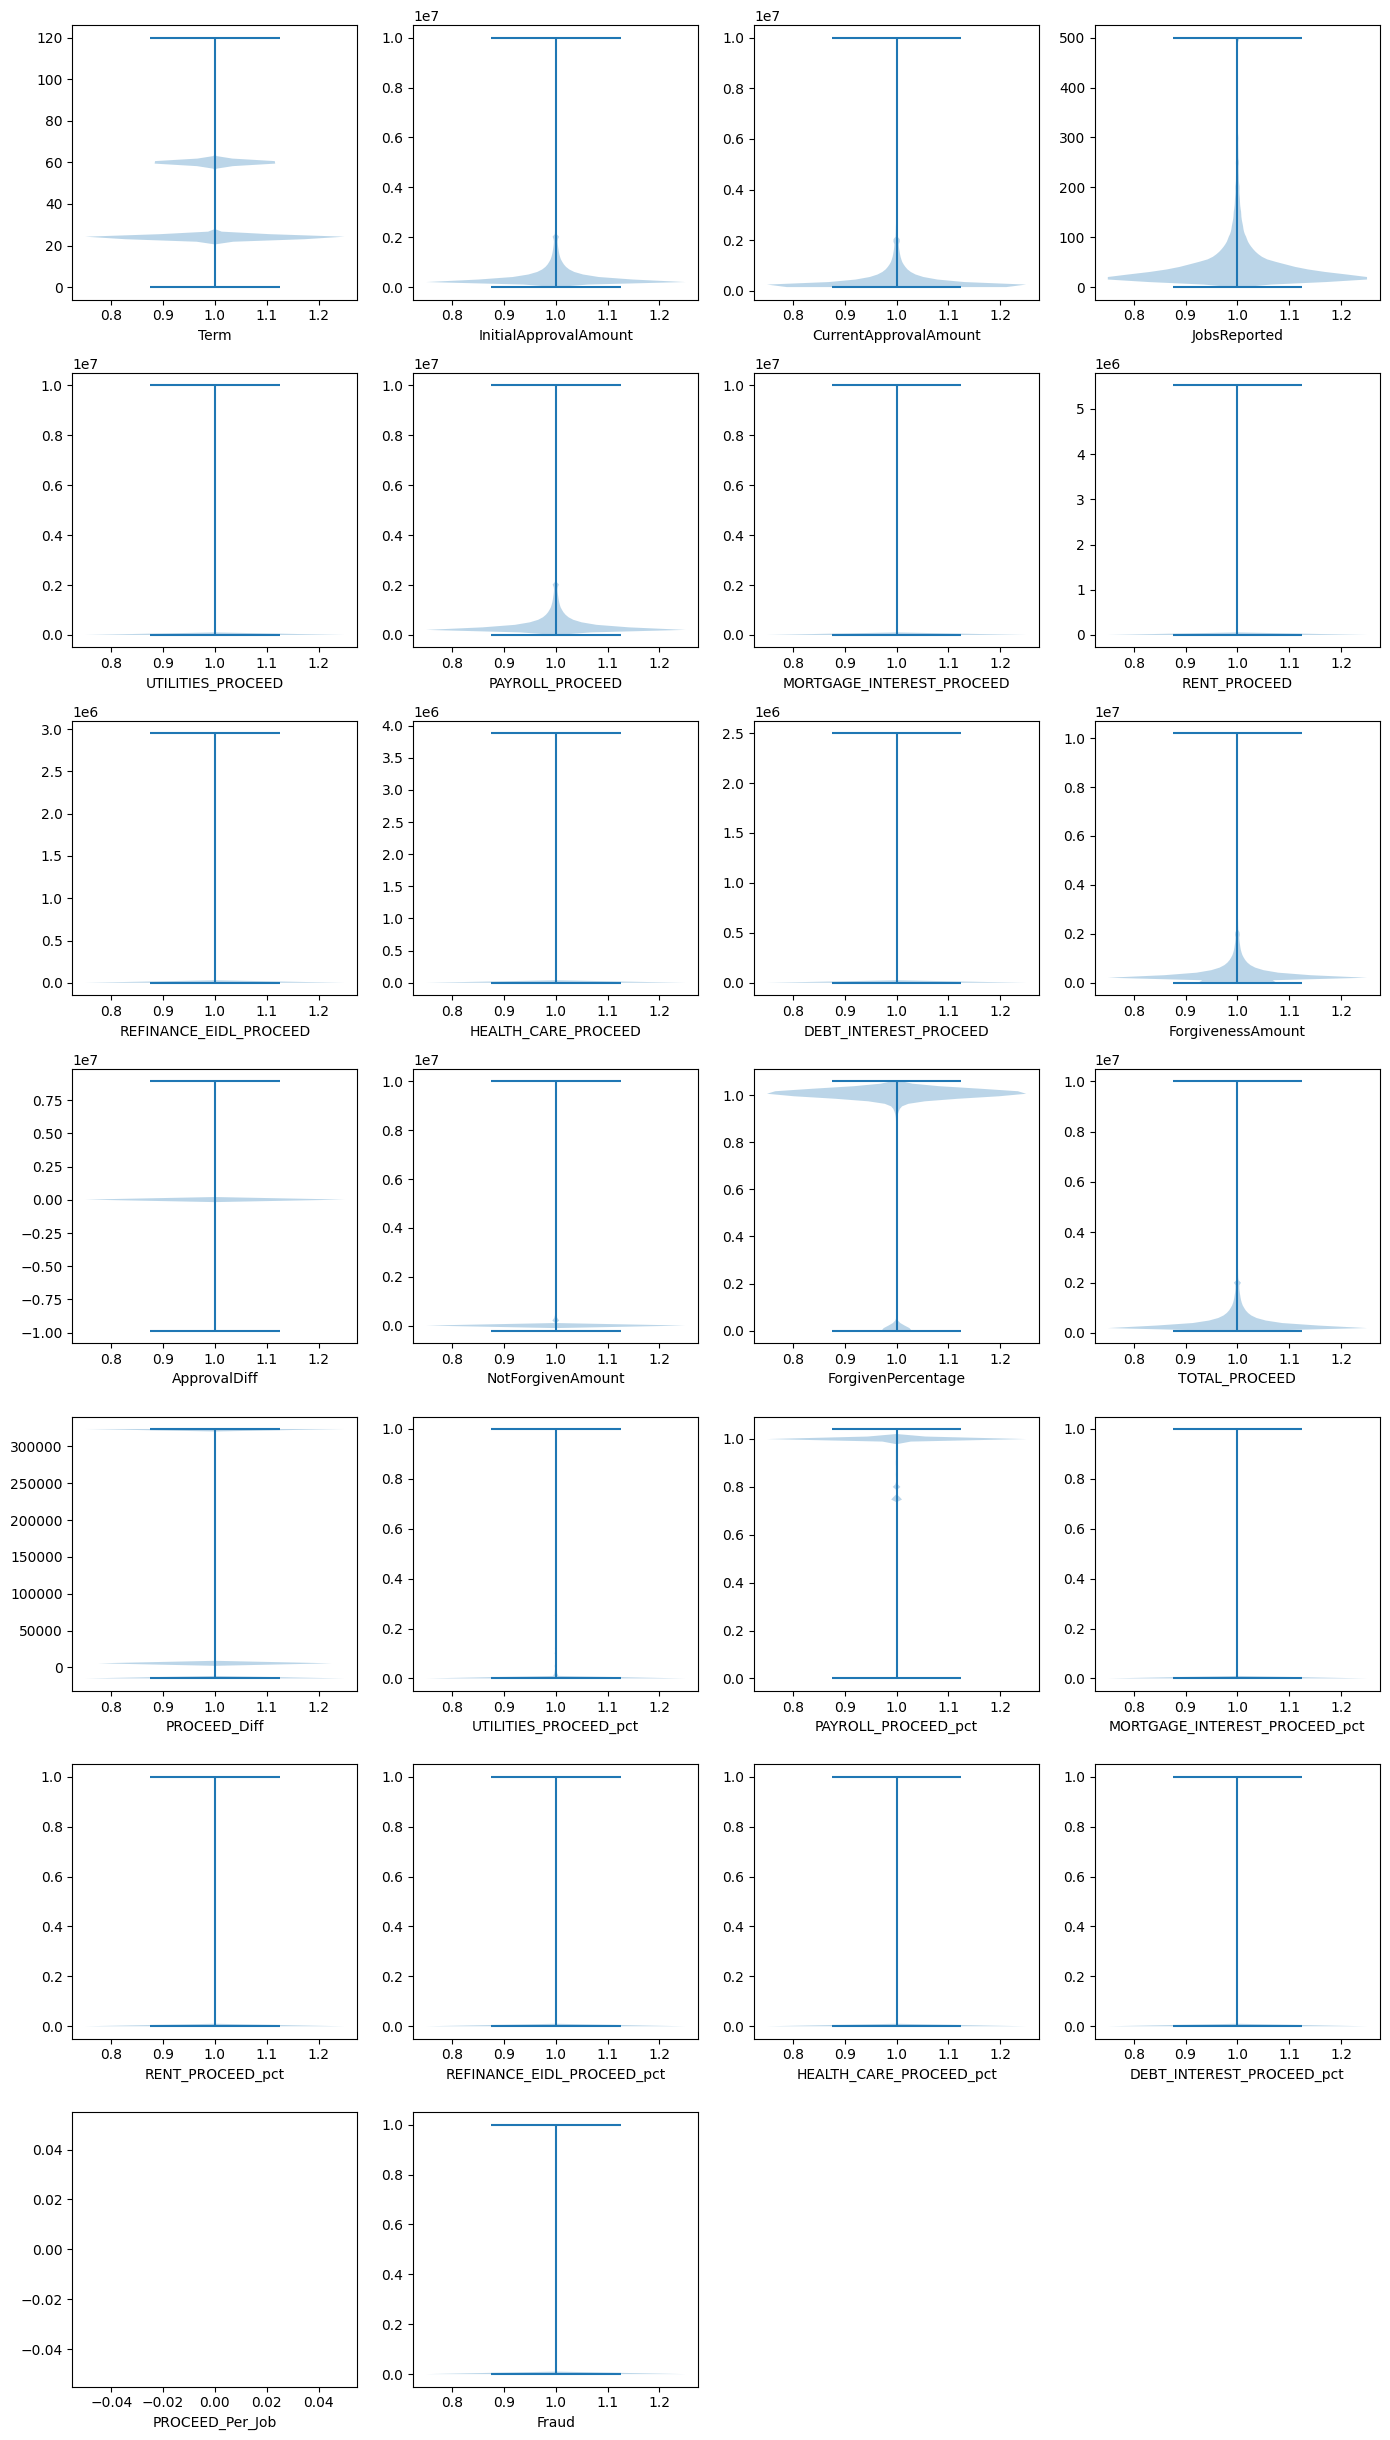

In [24]:
num_cols = 4
num_rows = (len(numeric_cols) + num_cols - 1) // num_cols
plt.figure(figsize=(num_cols * 3.5, num_rows * 3.5))
for (i,c) in enumerate(numeric_cols):
    plt.subplot(num_rows, num_cols, i+1)
    plt.violinplot(df[c])
    plt.xlabel(c)
plt.tight_layout()
None

## Boxplots

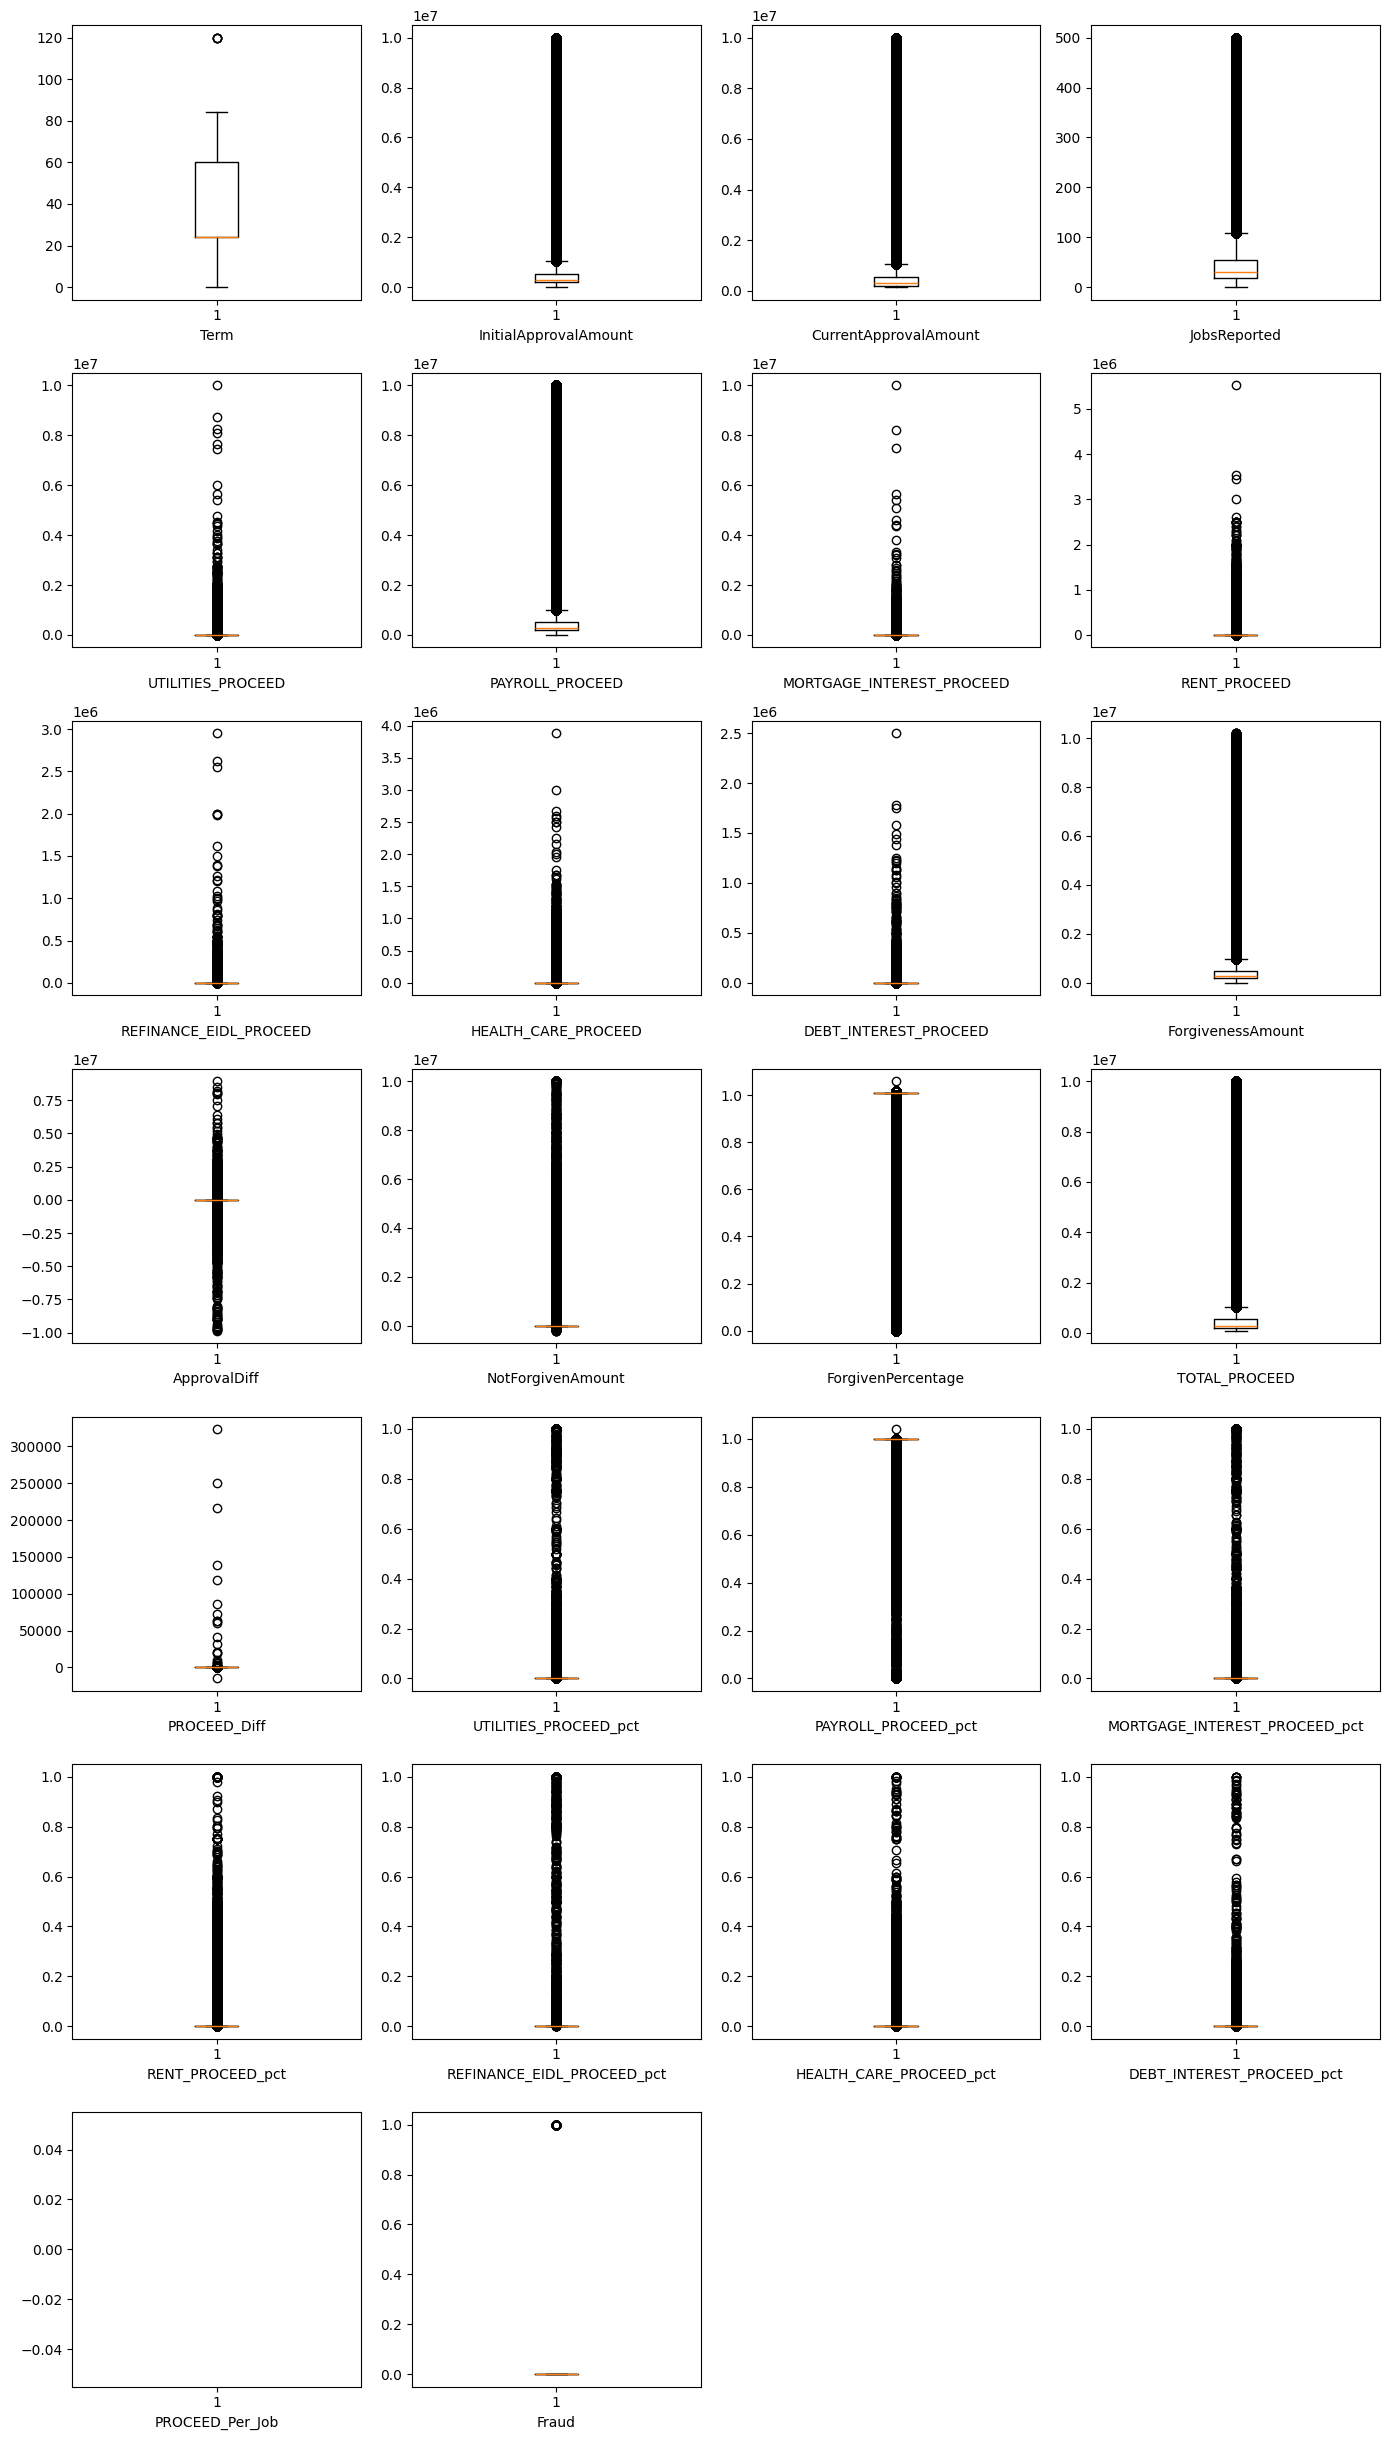

In [25]:
num_cols = 4
num_rows = (len(numeric_cols) + num_cols - 1) // num_cols
plt.figure(figsize=(num_cols * 3.5, num_rows * 3.5))
for (i,c) in enumerate(numeric_cols):
    plt.subplot(num_rows, num_cols, i+1)
    plt.boxplot(df[c])
    plt.xlabel(c)
plt.tight_layout()
None

## Plotting Categorical Columns

In [26]:
categorical_cols = [c for c in non_numeric_cols if df[c].nunique() <= 100]

In [27]:
set(non_numeric_cols) - set(categorical_cols)

{'DateApproved', 'ForgivenessDate', 'LoanStatusDate'}

In [28]:
date_columns = [
    'DateApproved',
    'ForgivenessDate',
    'LoanStatusDate',
]

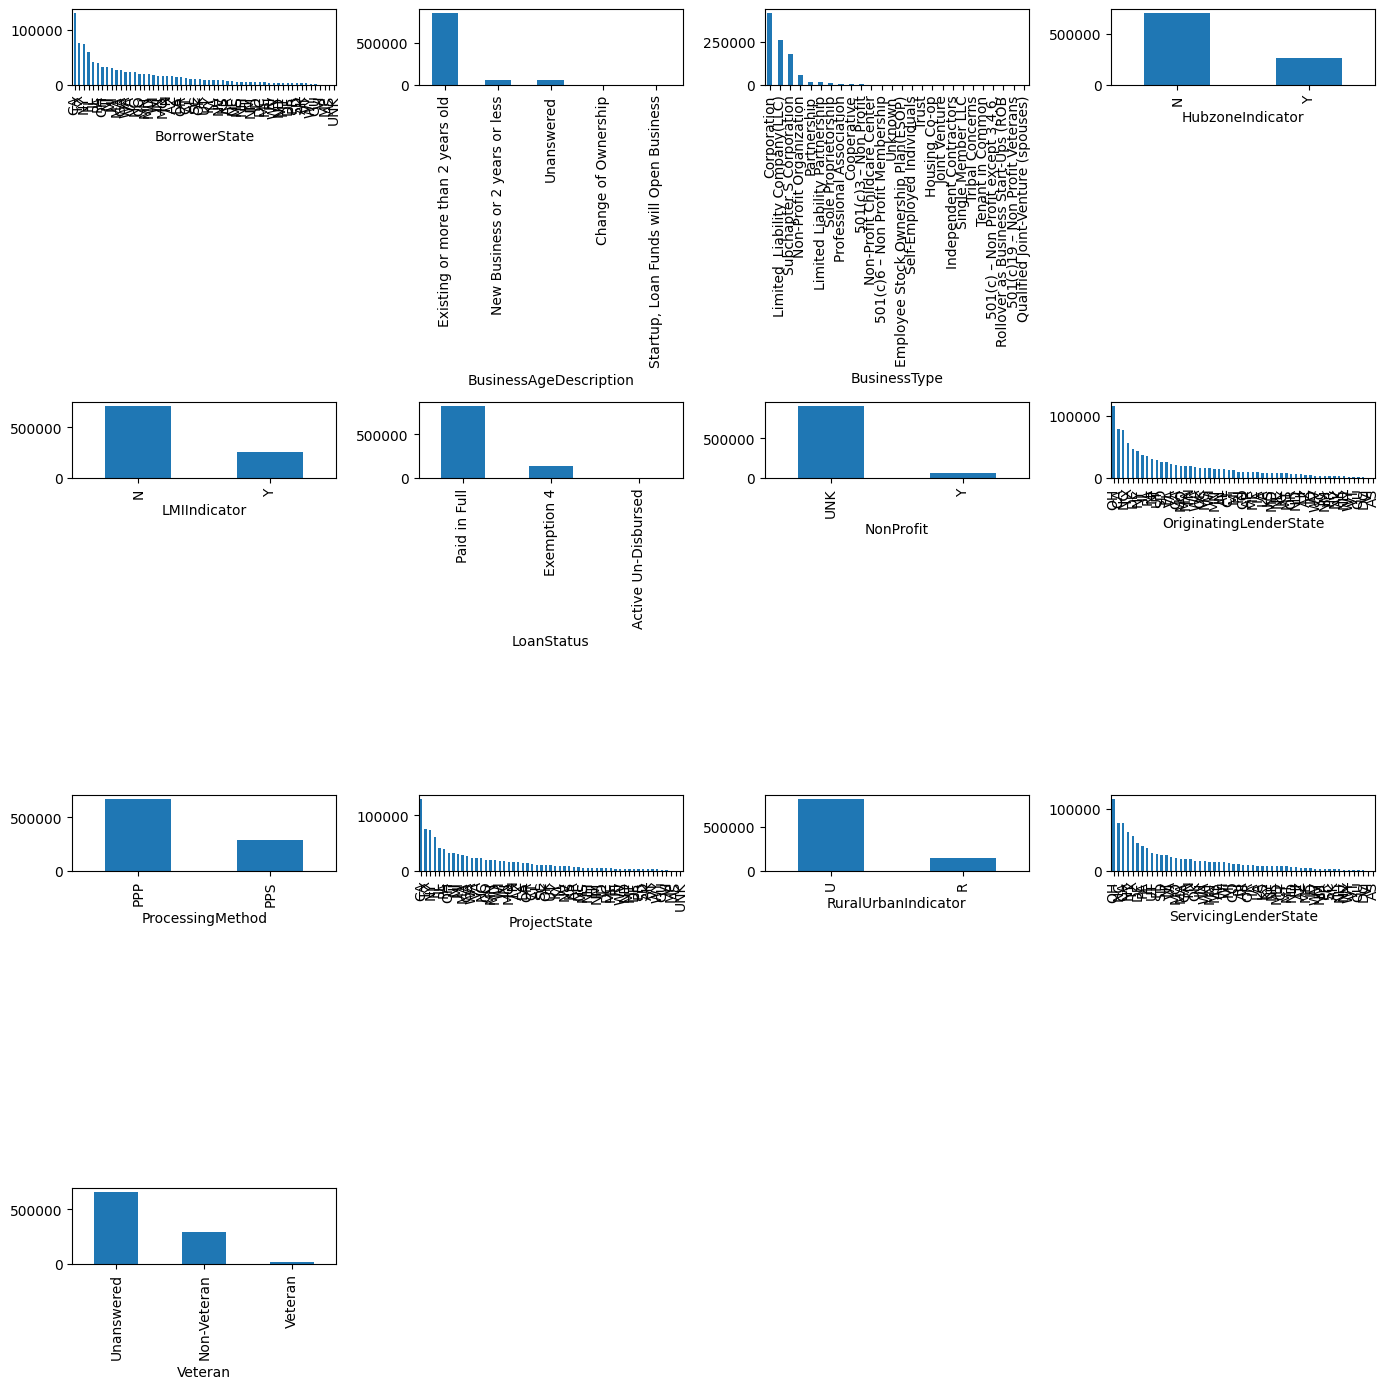

In [29]:
num_cols = 4
num_rows = (len(categorical_cols) + num_cols - 1) // num_cols
plt.figure(figsize=(num_cols * 3.5, num_rows * 3.5))
for (i,c) in enumerate(categorical_cols):
    plt.subplot(num_rows, num_cols, i+1)
    df[c].value_counts().plot(kind='bar')
    plt.xlabel(c)
plt.tight_layout()
None

## Encoding Date Features

In [30]:
df[df['Fraud'] == 1]['ForgivenessDate']

13864     1900-01-01
15420     1900-01-01
35250     1900-01-01
41252     2021-03-11
50004     1900-01-01
             ...    
915442    1900-01-01
918753    1900-01-01
924785    1900-01-01
966758    1900-01-01
966844    1900-01-01
Name: ForgivenessDate, Length: 95, dtype: object

In [31]:
for c in date_columns:
    print(df[c].head(5))
    print()

0    2020-05-01
1    2020-05-01
2    2020-05-01
3    2020-05-01
4    2020-05-01
Name: DateApproved, dtype: object

0    2020-11-20
1    2021-08-12
2    2021-02-10
3    2021-09-10
4    2021-04-08
Name: ForgivenessDate, dtype: object

0    2020-12-18
1    2021-09-28
2    2021-03-17
3    2021-10-16
4    2021-08-17
Name: LoanStatusDate, dtype: object



In [32]:
for c in date_columns:
    df[f"{c}_datetime"] = pd.to_datetime(df[c], format='%Y-%m-%d')
    print(df[f"{c}_datetime"].head(5))
    df[f"{c}_int"] = df[f"{c}_datetime"].astype(np.int64) // 10**9
    print(df[f"{c}_int"].head(5))
    df.drop([c, f"{c}_datetime"], axis=1, inplace=True)

0   2020-05-01
1   2020-05-01
2   2020-05-01
3   2020-05-01
4   2020-05-01
Name: DateApproved_datetime, dtype: datetime64[ns]
0    1588291200
1    1588291200
2    1588291200
3    1588291200
4    1588291200
Name: DateApproved_int, dtype: int64
0   2020-11-20
1   2021-08-12
2   2021-02-10
3   2021-09-10
4   2021-04-08
Name: ForgivenessDate_datetime, dtype: datetime64[ns]
0    1605830400
1    1628726400
2    1612915200
3    1631232000
4    1617840000
Name: ForgivenessDate_int, dtype: int64
0   2020-12-18
1   2021-09-28
2   2021-03-17
3   2021-10-16
4   2021-08-17
Name: LoanStatusDate_datetime, dtype: datetime64[ns]
0    1608249600
1    1632787200
2    1615939200
3    1634342400
4    1629158400
Name: LoanStatusDate_int, dtype: int64


## Encoding Categorical Features

In [33]:
categorical_cols

['BorrowerState',
 'BusinessAgeDescription',
 'BusinessType',
 'HubzoneIndicator',
 'LMIIndicator',
 'LoanStatus',
 'NonProfit',
 'OriginatingLenderState',
 'ProcessingMethod',
 'ProjectState',
 'RuralUrbanIndicator',
 'ServicingLenderState',
 'Veteran']

I am going to Ordinal Encode each of these due to the size of the data. We can later attempt One-Hot encoding.

In [34]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder()
enc.fit(df[categorical_cols])
enc.categories_

[array(['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL',
        'GA', 'GU', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA',
        'MD', 'ME', 'MI', 'MN', 'MO', 'MP', 'MS', 'MT', 'NC', 'ND', 'NE',
        'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI',
        'SC', 'SD', 'TN', 'TX', 'UNK', 'UT', 'VA', 'VI', 'VT', 'WA', 'WI',
        'WV', 'WY'], dtype=object),
 array(['Change of Ownership', 'Existing or more than 2 years old',
        'New Business or 2 years or less',
        'Startup, Loan Funds will Open Business', 'Unanswered'],
       dtype=object),
 array(['501(c) – Non Profit except 3,4,6,',
        '501(c)19 – Non Profit Veterans', '501(c)3 – Non Profit',
        '501(c)6 – Non Profit Membership', 'Cooperative', 'Corporation',
        'Employee Stock Ownership Plan(ESOP)', 'Housing Co-op',
        'Independent Contractors', 'Joint Venture',
        'Limited  Liability Company(LLC)', 'Limited Liability Partnership',
        'Non-Profit

In [35]:
df[categorical_cols] = enc.transform(df[categorical_cols])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 968532 entries, 0 to 968531
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ProcessingMethod               968532 non-null  float64
 1   BorrowerState                  968532 non-null  float64
 2   LoanStatus                     968532 non-null  float64
 3   Term                           968532 non-null  int64  
 4   InitialApprovalAmount          968532 non-null  float64
 5   CurrentApprovalAmount          968532 non-null  float64
 6   ServicingLenderState           968532 non-null  float64
 7   RuralUrbanIndicator            968532 non-null  float64
 8   HubzoneIndicator               968532 non-null  float64
 9   LMIIndicator                   968532 non-null  float64
 10  BusinessAgeDescription         968532 non-null  float64
 11  ProjectState                   968532 non-null  float64
 12  JobsReported                  

## Conclusions

The dataset has a large number of instances (over 900,000) and features (66). The features are a mix of categorical and numeric. There are also some string features such as names or street addresses, which will not be useful for modeling. There are also a number of protected features including gender and race, which could produce biased models.

Some numeric features like the amounts and proceeds have a skewed distribution. There are a number of binary numeric features which are bimodal

Based on the boxplots, there are outliers for almost every numeric feature. This is not surprising since there are almost 1,000,000 instances in the dataset

After encoding categorical and datetime features as well as dropping features which cannot be used for modeling, we are 42 usable features.

## Bivariate Analysis

#### Scatterplots

#### Correlations

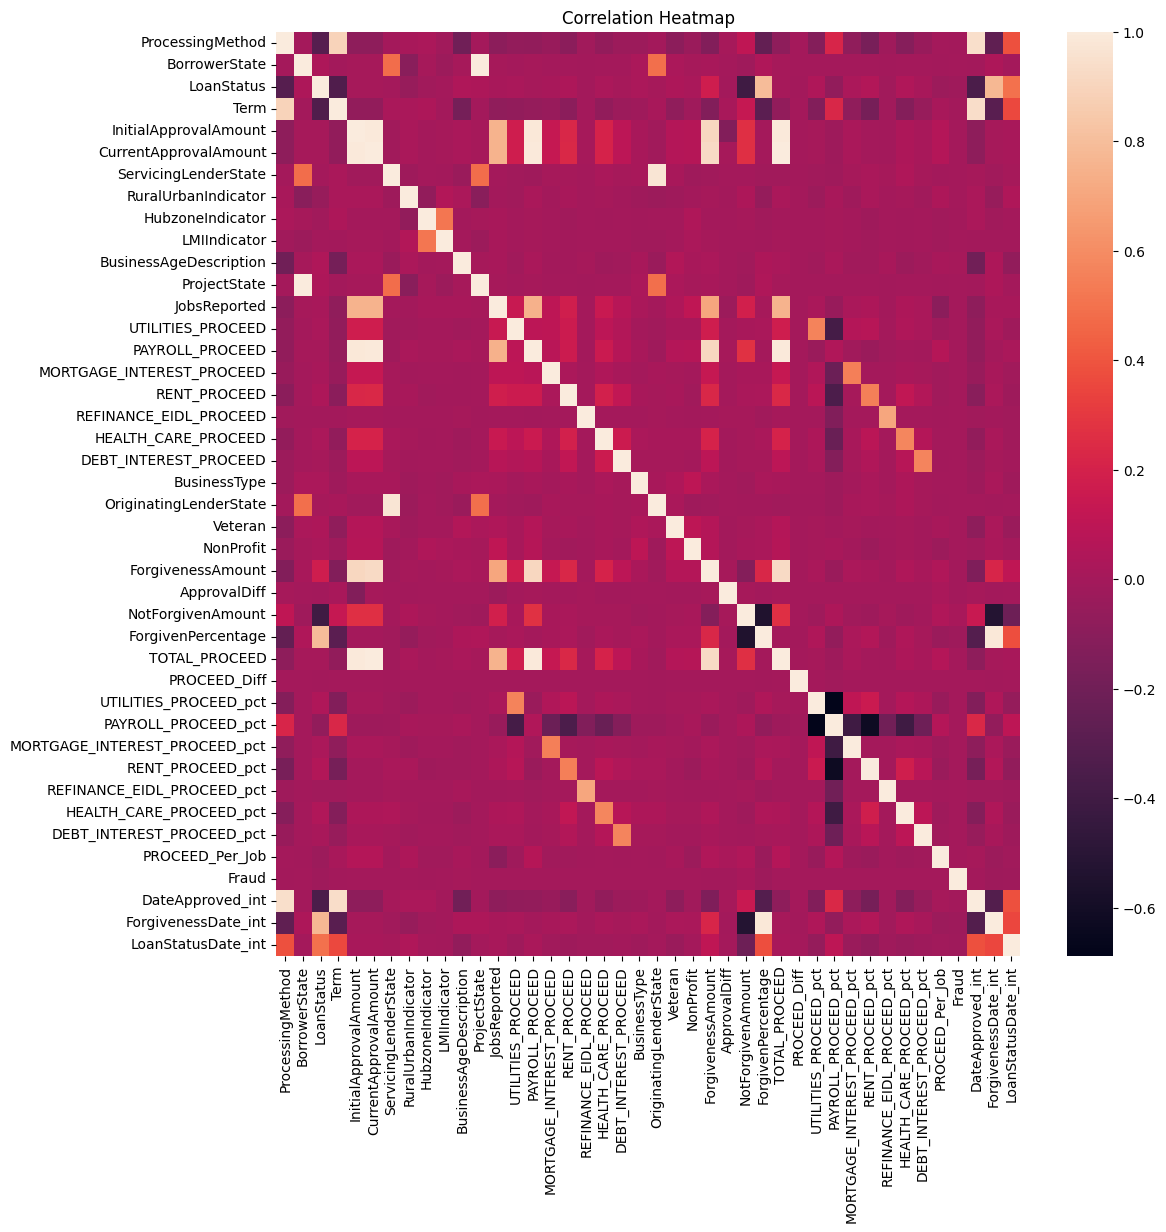

In [37]:
plt.figure(figsize=(12, 12)) # Adjust the width and height as needed
sns.heatmap(df.corr(numeric_only=True))
plt.title("Correlation Heatmap")
plt.savefig("ppp_figs/correlation.png", bbox_inches='tight')

In [38]:
df_pos = df[df['Fraud'] == 1]
df_neg = df[df['Fraud'] == 0]

# Sample from the majority class to reach your desired balance
# Adjust n or fraction as needed
df_neg_sample = df_neg.sample(n=len(df_pos)) 

# Combine and shuffle
balanced_df = pd.concat([df_pos, df_neg_sample]).sample(frac=1)

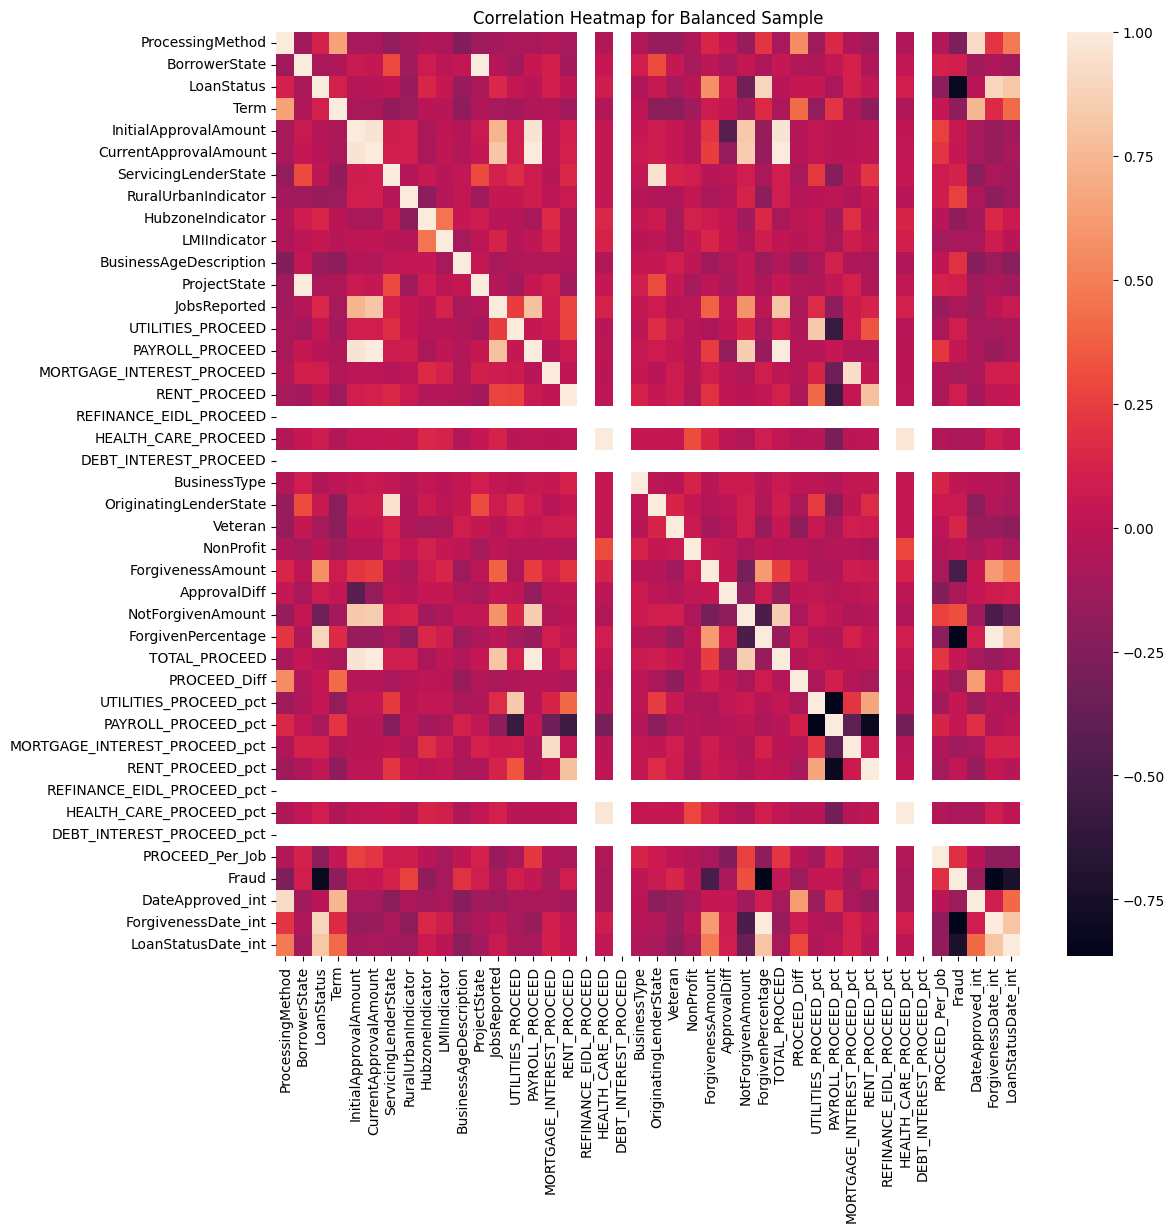

In [39]:
plt.figure(figsize=(12, 12)) # Adjust the width and height as needed
sns.heatmap(balanced_df.corr(numeric_only=True))
plt.title("Correlation Heatmap for Balanced Sample")
plt.savefig("ppp_figs/balanced_correlations.png", bbox_inches='tight')

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\pandas\plotting\_matplotlib\misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\pandas\plotting\_matplotlib\misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\pandas\plotting\_matplotlib\misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])
C:\Users\caleb\AppData\Local\Temp\ipykernel_1476\4037872222.py:15: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


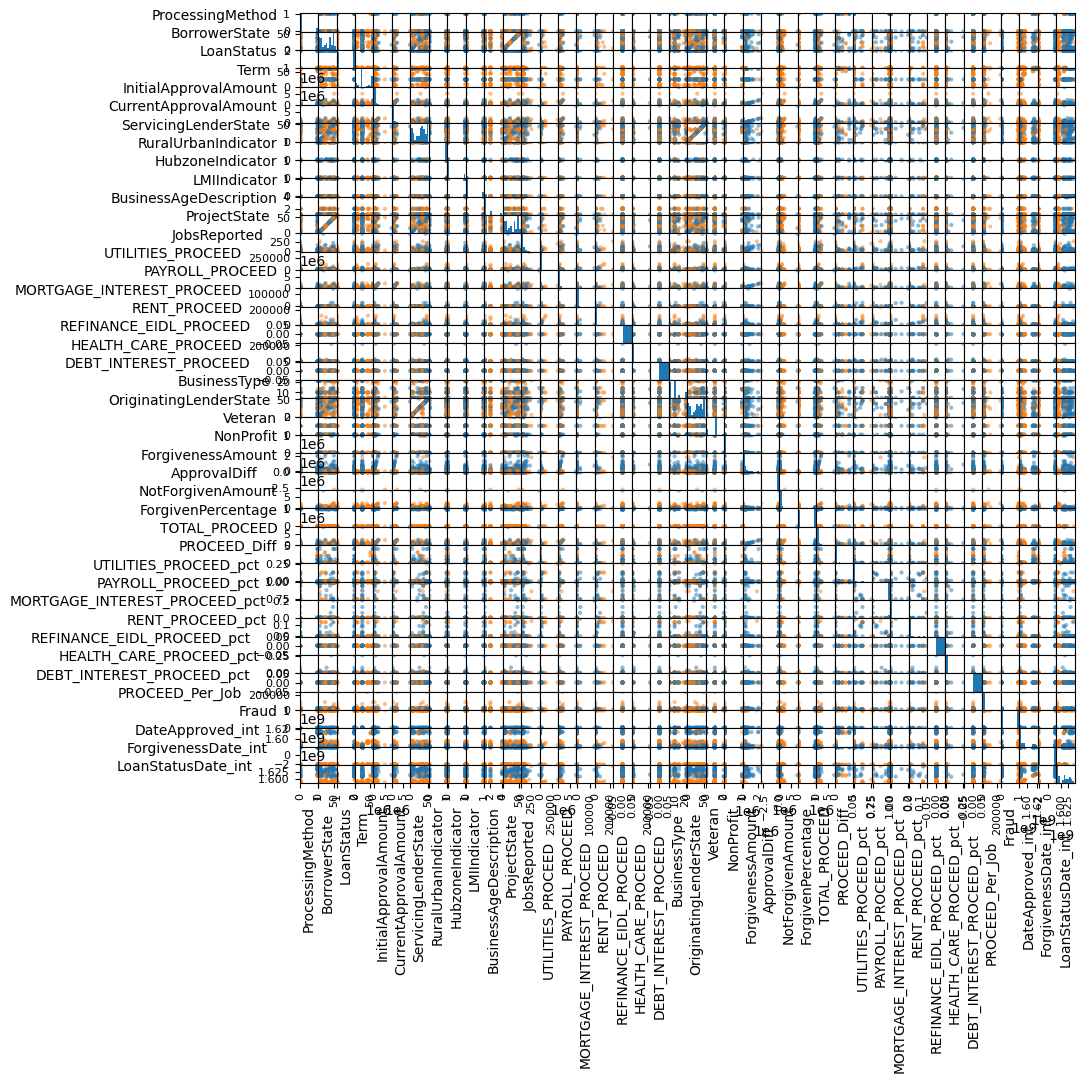

In [40]:
df_colored = balanced_df.copy()
df_colored["color"] = df_colored["Fraud"].map(
    dict(
        zip(df_colored['Fraud'].unique(), plt.rcParams['axes.prop_cycle'].by_key()['color'])
    )
) 

# Commenting this code since it slows down execution significantly. The output can be viewed in the scatter_matrix.png figure
axes = pd.plotting.scatter_matrix(df_colored, color=df_colored['color'], figsize=(10,10))
# text rotation snippet from https://stackoverflow.com/questions/58623528/pandas-scatter-matrix-labels-vertical-x-and-horizontal-y-without-being-cut
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.savefig('ppp_figs/scatter_matrix.png')

# img = mpimg.imread('scatter_matrix.png')
# plt.imshow(img)
# plt.axis('off')
None

In [41]:
df_colored

,ProcessingMethod,BorrowerState,LoanStatus,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,...,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud,DateApproved_int,ForgivenessDate_int,LoanStatusDate_int,color
897860,0.0,50.0,2.0,24,1300000.00,1312500.00,29.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,8928.57,0,1586563200,1613520000,1616112000,#1f77b4
828553,0.0,47.0,1.0,10,565082.00,565082.00,36.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,19485.59,1,1590537600,-2208988800,1590537600,#ff7f0e
782910,0.0,44.0,1.0,46,727000.00,727000.00,40.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,11539.68,1,1593043200,-2208988800,1593043200,#ff7f0e
743910,0.0,41.0,2.0,24,671400.00,671400.00,40.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,26856.00,0,1586908800,1621555200,1623110400,#1f77b4
717387,0.0,39.0,2.0,24,308000.00,308000.00,38.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,17111.11,0,1586476800,1604534400,1607385600,#1f77b4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833777,0.0,47.0,1.0,40,455916.65,455916.65,5.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,13026.19,1,1593129600,-2208988800,1593129600,#ff7f0e
417730,0.0,21.0,1.0,60,214926.00,214926.00,7.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,13432.88,1,1596844800,-2208988800,1596844800,#ff7f0e
832944,0.0,47.0,1.0,60,470880.00,470880.00,33.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,12073.85,1,1593216000,-2208988800,1593216000,#ff7f0e
163285,0.0,5.0,2.0,24,152085.00,152085.00,44.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4473.09,0,1588291200,1625184000,1628726400,#1f77b4


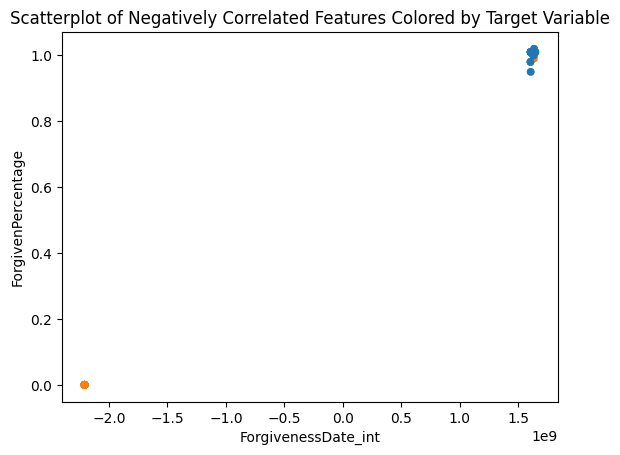

In [42]:
_ = df_colored.plot.scatter("ForgivenessDate_int", "ForgivenPercentage", c="color")
plt.title("Scatterplot of Negatively Correlated Features Colored by Target Variable")
plt.savefig("ppp_figs/scatter_forgivenessdate_forgivenpercentage")
None

#### Boxplot of Outcomes by Category

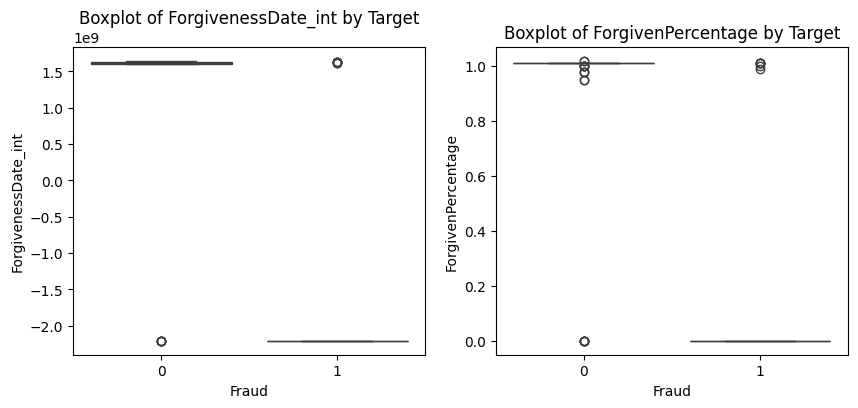

In [43]:
fig, ax = plt.subplots(ncols=2, figsize=(10,4))

sns.boxplot(x="Fraud", y="ForgivenessDate_int", data=balanced_df, ax=ax[0])
ax[0].set_title('Boxplot of ForgivenessDate_int by Target')

sns.boxplot(x="Fraud", y="ForgivenPercentage", data=balanced_df, ax=ax[1])
ax[1].set_title('Boxplot of ForgivenPercentage by Target')

plt.savefig('ppp_figs/outliers_by_target')
None

In [44]:
df['ProcessingMethod']

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
968527    0.0
968528    0.0
968529    1.0
968530    0.0
968531    0.0
Name: ProcessingMethod, Length: 968532, dtype: float64

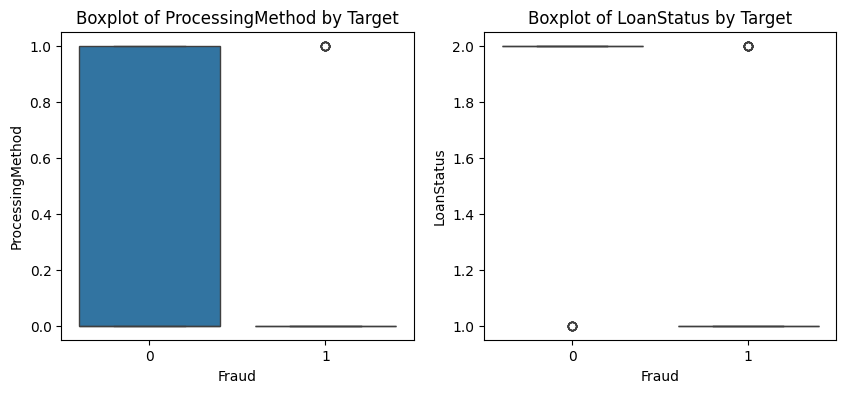

In [45]:
fig, ax = plt.subplots(ncols=2, figsize=(10,4))

sns.boxplot(x="Fraud", y="ProcessingMethod", data=balanced_df, ax=ax[0])
ax[0].set_title('Boxplot of ProcessingMethod by Target')

sns.boxplot(x="Fraud", y="LoanStatus", data=balanced_df, ax=ax[1])
ax[1].set_title('Boxplot of LoanStatus by Target')

plt.savefig('ppp_figs/outliers_by_target')
None

In [46]:
balanced_df

,ProcessingMethod,BorrowerState,LoanStatus,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,...,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud,DateApproved_int,ForgivenessDate_int,LoanStatusDate_int
897860,0.0,50.0,2.0,24,1300000.00,1312500.00,29.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,8928.57,0,1586563200,1613520000,1616112000
828553,0.0,47.0,1.0,10,565082.00,565082.00,36.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,19485.59,1,1590537600,-2208988800,1590537600
782910,0.0,44.0,1.0,46,727000.00,727000.00,40.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,11539.68,1,1593043200,-2208988800,1593043200
743910,0.0,41.0,2.0,24,671400.00,671400.00,40.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,26856.00,0,1586908800,1621555200,1623110400
717387,0.0,39.0,2.0,24,308000.00,308000.00,38.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,17111.11,0,1586476800,1604534400,1607385600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833777,0.0,47.0,1.0,40,455916.65,455916.65,5.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,13026.19,1,1593129600,-2208988800,1593129600
417730,0.0,21.0,1.0,60,214926.00,214926.00,7.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,13432.88,1,1596844800,-2208988800,1596844800
832944,0.0,47.0,1.0,60,470880.00,470880.00,33.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,12073.85,1,1593216000,-2208988800,1593216000
163285,0.0,5.0,2.0,24,152085.00,152085.00,44.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4473.09,0,1588291200,1625184000,1628726400


In [47]:
df_pos[df_pos['CurrentApprovalAmount'] == 150_000 ]

,ProcessingMethod,BorrowerState,LoanStatus,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,...,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud,DateApproved_int,ForgivenessDate_int,LoanStatusDate_int
35250,1.0,4.0,1.0,60,150000.0,150000.0,33.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,18749.62,1,1613174400,-2208988800,1613174400
265797,0.0,10.0,2.0,24,150000.0,150000.0,33.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9375.00,1,1588204800,1625097600,1634947200
722548,0.0,39.0,1.0,9,150000.0,150000.0,38.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,7500.00,1,1588118400,-2208988800,1588118400


#### Crosstab Tables

#### Grouped Means